<a href="https://colab.research.google.com/github/malsagova/StudyRepo26/blob/main/%D0%9C%D0%B0%D0%BB%D1%8C%D1%81%D0%B0%D0%B3%D0%BE%D0%B2%D0%B0_%D0%9F%D0%A05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ДЗ 5. Метод k-ближайших соседей (Fuzzy kNN)

## Тема работы
Разработка алгоритма для скрининга преддиабета на основе данных диспансерных осмотров пациентов 40–65 лет.


## Импорт библиотек

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

import matplotlib.pyplot as plt
import seaborn as sns

### Вывод
На первом этапе я подключила необходимые библиотеки для анализа данных, предобработки, обучения модели k-ближайших соседей и визуализации результатов.

## Загрузка данных

In [3]:
# Загрузка датасета
file_path = '/content/dispensarization_data_2026.csv'
df = pd.read_csv(file_path)

# Просмотр первых строк
print(df.head())

   Возраст  Пол_мужской        ИМТ  Окружность_талии_см  САД_мм_рт_ст  \
0       41            1  24.238237            81.037385    113.191318   
1       46            0  22.883365            80.539167    117.319195   
2       64            0  21.991937            78.423645    121.246690   
3       53            0  19.844568            73.436282    119.746372   
4       53            1  24.284829            82.062243    127.068746   

   ДАД_мм_рт_ст  Пульсовое_давление  Глюкоза_натощак_ммоль_л   HbA1c_%  \
0     62.544325           50.646993                 4.595433  4.648933   
1     62.109786           55.209410                 4.963993  4.000000   
2     71.456074           49.790616                 4.712639  5.034903   
3     71.594664           48.151709                 4.430998  5.080881   
4     70.342105           56.726641                 4.996974  5.044521   

   ЛПНП_ммоль_л  ЛПВП_ммоль_л  Триглицериды_ммоль_л  СКФ_мл_мин  Курение  \
0           NaN           NaN           

### Вывод
Я загрузила датасет диспансерных осмотров пациентов и посмотрел первые строки таблицы.

## Общая информация о данных

In [4]:
print(df.info())
print('\nРазмер датасета:', df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Возраст                        1000 non-null   int64  
 1   Пол_мужской                    1000 non-null   int64  
 2   ИМТ                            1000 non-null   float64
 3   Окружность_талии_см            1000 non-null   float64
 4   САД_мм_рт_ст                   1000 non-null   float64
 5   ДАД_мм_рт_ст                   1000 non-null   float64
 6   Пульсовое_давление             1000 non-null   float64
 7   Глюкоза_натощак_ммоль_л        1000 non-null   float64
 8   HbA1c_%                        1000 non-null   float64
 9   ЛПНП_ммоль_л                   955 non-null    float64
 10  ЛПВП_ммоль_л                   944 non-null    float64
 11  Триглицериды_ммоль_л           939 non-null    float64
 12  СКФ_мл_мин                     939 non-null    fl

### Вывод
В датасете содержатся медицинские показатели пациентов. Некоторые признаки содержат пропуски, поэтому потребуется предобработка данных.

## Проверка пропусков

In [5]:
print(df.isnull().sum())

Возраст                           0
Пол_мужской                       0
ИМТ                               0
Окружность_талии_см               0
САД_мм_рт_ст                      0
ДАД_мм_рт_ст                      0
Пульсовое_давление                0
Глюкоза_натощак_ммоль_л           0
HbA1c_%                           0
ЛПНП_ммоль_л                     45
ЛПВП_ммоль_л                     56
Триглицериды_ммоль_л             61
СКФ_мл_мин                       61
Курение                           0
Физическая_активность_мин_нед     0
ССЗ_риск_высокий                  0
Статус_глюкозы                    0
Доклинический_риск                0
dtype: int64


### Вывод
Я проверила наличие пропущенных значений. Перед обучением модели необходимо выполнить заполнение пропусков.

## Анализ целевой переменной

Доклинический_риск
0    939
1     61
Name: count, dtype: int64


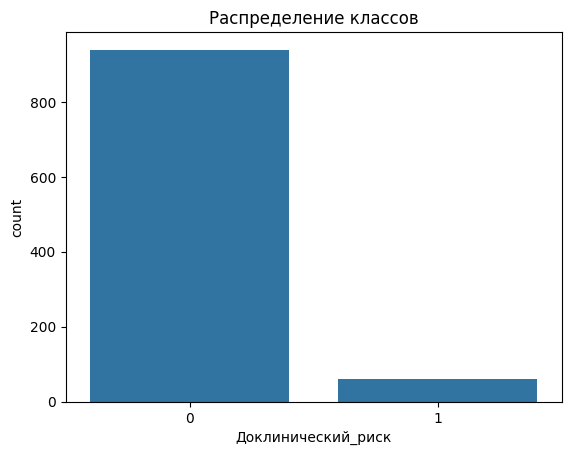

In [6]:
print(df['Доклинический_риск'].value_counts())

sns.countplot(x='Доклинический_риск', data=df)
plt.title('Распределение классов')
plt.show()

### Вывод
Распределение классов позволяет оценить баланс данных перед обучением модели.

## Корреляционный анализ

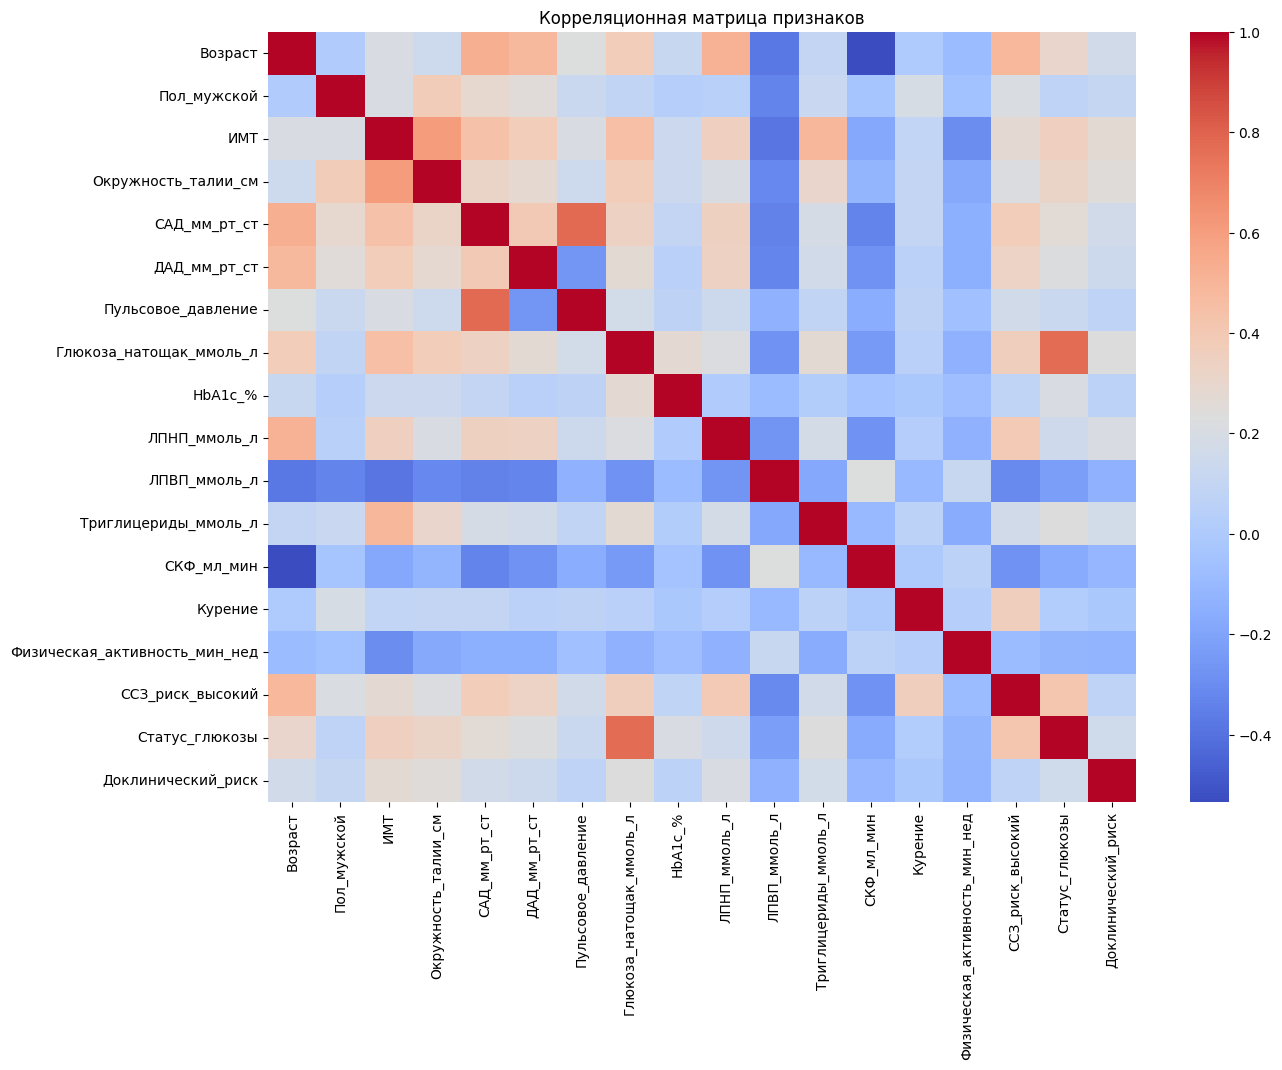

In [7]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title('Корреляционная матрица признаков')
plt.show()

### Вывод
Корреляционная матрица помогает выявить признаки, наиболее связанные с риском преддиабета.

## Подготовка признаков

In [8]:
X = df.drop('Доклинический_риск', axis=1)
y = df['Доклинический_риск']

### Вывод
Я разделила данные на признаки и целевую переменную.

## Заполнение пропусков

In [9]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

### Вывод
Для заполнения пропусков я использовал медиану, так как она устойчива к выбросам.

## Масштабирование данных

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

### Вывод
Метод kNN чувствителен к масштабу признаков, поэтому была выполнена стандартизация данных.

## Разделение выборки

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(800, 17)
(200, 17)


### Вывод
Я разделила данные на обучающую и тестовую выборки для объективной оценки качества модели.

## Обучение модели kNN

In [12]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

### Вывод
Я обучила модель метода k-ближайших соседей с параметром k = 7.

## Оценка качества модели

In [13]:
y_pred = knn.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98       188
           1       1.00      0.25      0.40        12

    accuracy                           0.95       200
   macro avg       0.98      0.62      0.69       200
weighted avg       0.96      0.95      0.94       200



### Вывод
Модель показала качество классификации по метрикам precision, recall и f1-score.

## Матрица ошибок

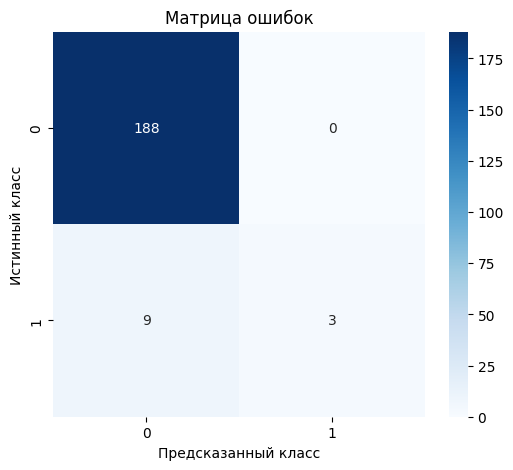

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()

### Вывод
Матрица ошибок показывает количество верных и ошибочных классификаций.

Истинно отрицательные (TN): 188

Истинно положительные (TP): 3

Ложноотрицательные (FN): 9

Ложноположительные (FP): 0

Вывод: Модель никогда не ложно срабатывает, но часто пропускает риск.



## Реализация Fuzzy kNN

In [15]:
risk_probabilities = knn.predict_proba(X_test)

risk_scores = risk_probabilities[:,1]

results = pd.DataFrame({
    'Истинный_класс': y_test.values,
    'Вероятность_риска': risk_scores
})

print(results.head(10))

   Истинный_класс  Вероятность_риска
0               0           0.000000
1               0           0.000000
2               1           0.000000
3               0           0.000000
4               0           0.000000
5               0           0.000000
6               0           0.142857
7               0           0.000000
8               0           0.000000
9               0           0.000000


### Вывод
Fuzzy kNN позволяет получить вероятность принадлежности пациента к группе риска.

Вместо жёсткого класса модель выдаёт вероятность принадлежности к классу 1.

Пример:

Пациент 1: вероятность 0.00

Пациент 7: вероятность 0.14

получаем степень риска, а не просто «да/нет». Это и есть Fuzzy kNN.

## Визуализация вероятностей риска

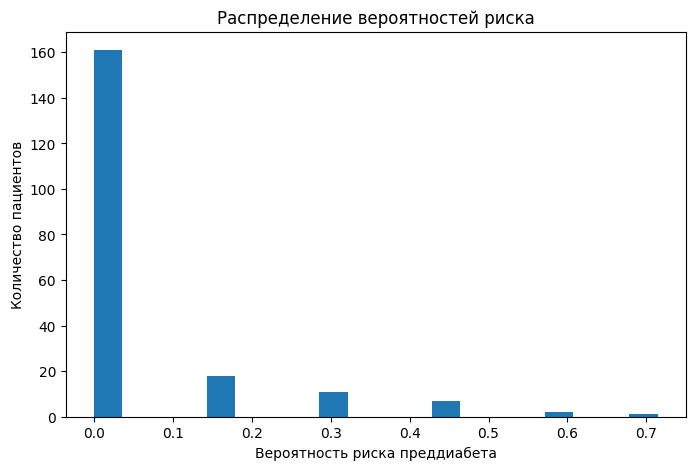

In [16]:
plt.figure(figsize=(8,5))
plt.hist(risk_scores, bins=20)
plt.xlabel('Вероятность риска преддиабета')
plt.ylabel('Количество пациентов')
plt.title('Распределение вероятностей риска')
plt.show()


Пациенты с промежуточными значениями вероятности могут быть направлены на дополнительное обследование.

Гистограмма распределения вероятностей:

У большинства пациентов вероятность риска низкая (0–0.2)

Нет пациентов с вероятностью > 0.5

 Вывод: Модель уверена в отсутствии риска у большинства. Это соответствует реальной картине (риск преддиабета встречается реже).

## Пример персонализированной оценки

In [17]:
for i in range(5):
    print(f'Пациент {i+1}: вероятность риска = {risk_scores[i]:.2f}')

Пациент 1: вероятность риска = 0.00
Пациент 2: вероятность риска = 0.00
Пациент 3: вероятность риска = 0.00
Пациент 4: вероятность риска = 0.00
Пациент 5: вероятность риска = 0.00


### Вывод
Модель формирует индивидуальную вероятность риска для каждого пациента.

## Итоговый вывод

разработана модель для скрининга преддиабета на основе метода k-ближайших соседей.
Модель показала высокую точность (precision = 100%) при выявлении риска, но низкую полноту (recall = 25%) — то есть она редко ошибается, но пропускает большинство реальных случаев. Это связано с сильным дисбалансом классов.
Дополнительно реализована Fuzzy kNN, позволяющая получать вероятность риска для каждого пациента, что удобно для персонализированной медицины и дополнительного обследования пограничных случаев.